# Drone Object Detection with DETR (Detection Transformer)

## Overview
This notebook fine-tunes a DETR (Detection Transformer) model for object detection to locate drones in images with bounding boxes. Unlike the classification model, this model predicts WHERE drones are located in images.

## Dataset
- **Source**: Hibou-Foundation/computer-vision
- **Task**: Object Detection (bounding box prediction)
- **Classes**: drone
- **Annotations**: Bounding boxes in YOLO format (normalized: x_center, y_center, width, height)


## 1. Setup and Dependencies


In [1]:
# Install required packages if needed
# !pip install transformers datasets torch torchvision Pillow matplotlib seaborn scikit-learn accelerate -q
# !pip install pycocotools -q  # For COCO evaluation metrics


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
from datasets import load_dataset, DatasetDict
from transformers import (
    DetrImageProcessor,
    DetrForObjectDetection,
    TrainingArguments,
    Trainer
)
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import os
from tqdm.auto import tqdm
import random
from typing import Dict, List, Tuple, Optional
import json

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [3]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Random seeds set for reproducibility")


Using device: cuda
GPU: NVIDIA A10
CUDA Version: 12.8
Random seeds set for reproducibility


## 2. Dataset Loading and Exploration


In [4]:
# Load dataset from Hugging Face
dataset_name = "Hibou-Foundation/computer-vision"
print(f"Loading dataset: {dataset_name}")

# Load the dataset
dataset = load_dataset(dataset_name)

# Check dataset structure
print("\nDataset structure:")
print(dataset)
print("\nDataset features:")
print(dataset['train_validation_test'].features)
print(f"\nTotal samples: {len(dataset['train_validation_test'])}")


Loading dataset: Hibou-Foundation/computer-vision

Dataset structure:
DatasetDict({
    train_validation_test: Dataset({
        features: ['image', 'class_id', 'class_name', 'box', 'name', 'raw_label'],
        num_rows: 4614
    })
})

Dataset features:
{'image': Image(mode=None, decode=True), 'class_id': Value('int64'), 'class_name': Value('string'), 'box': List(Value('string')), 'name': Value('string'), 'raw_label': Value('string')}

Total samples: 4614


In [5]:
# Explore bounding box format
full_dataset = dataset['train_validation_test']
sample = full_dataset[0]

print("Sample data structure:")
print(f"Image size: {sample['image'].size}")
print(f"Class ID: {sample['class_id']}")
print(f"Class name: {sample['class_name']}")
print(f"Bounding box (normalized YOLO format): {sample['box']}")
print(f"Raw label: {sample['raw_label']}")

# Bounding boxes are in YOLO format: [x_center, y_center, width, height] (normalized 0-1)
# Some images may have multiple objects (multiple bounding boxes)


Sample data structure:
Image size: (1280, 720)
Class ID: 0
Class name: drone
Bounding box (normalized YOLO format): ['0.539758', '0.325448', '0.063850', '0.052038']
Raw label: 0 0.539758 0.325448 0.063850 0.052038


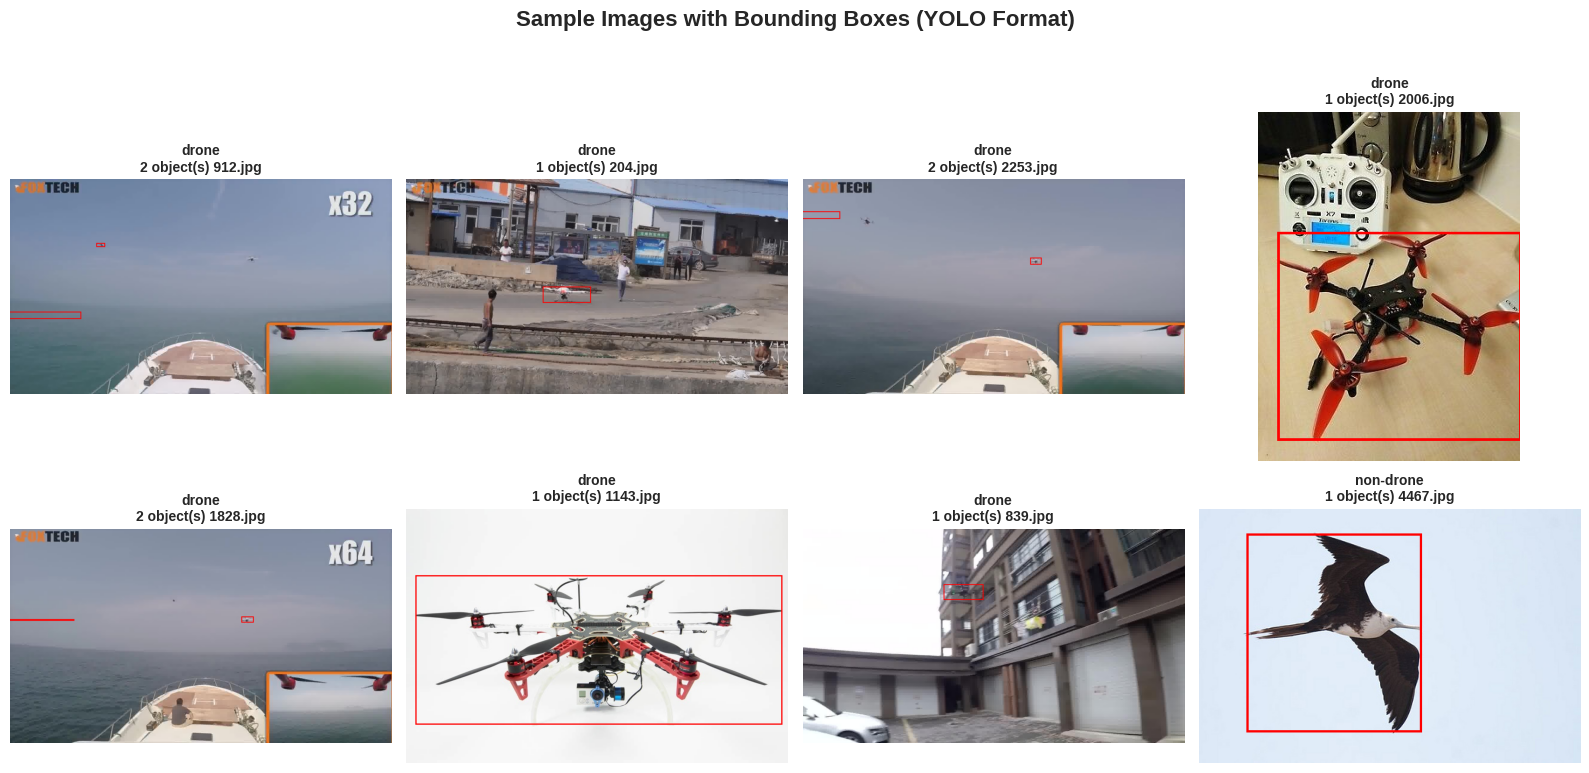

In [6]:
# Visualize sample images with bounding boxes
def draw_bbox_yolo(image, bbox_list, color='red', linewidth=2):
    """Draw bounding boxes on image from YOLO format (normalized center coordinates)."""
    from PIL import ImageDraw
    
    img_copy = image.copy()
    draw = ImageDraw.Draw(img_copy)
    img_width, img_height = image.size
    
    # Process boxes (each box is 4 values: x_center, y_center, width, height)
    for i in range(0, len(bbox_list), 4):
        if i + 3 < len(bbox_list):
            x_center = float(bbox_list[i]) * img_width
            y_center = float(bbox_list[i+1]) * img_height
            width = float(bbox_list[i+2]) * img_width
            height = float(bbox_list[i+3]) * img_height
            
            # Convert to top-left corner coordinates
            x1 = x_center - width / 2
            y1 = y_center - height / 2
            x2 = x_center + width / 2
            y2 = y_center + height / 2
            
            draw.rectangle([x1, y1, x2, y2], outline=color, width=linewidth)
    
    return img_copy

# Show sample images with bounding boxes
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

sample_indices = random.sample(range(len(full_dataset)), min(8, len(full_dataset)))

for idx, sample_idx in enumerate(sample_indices):
    item = full_dataset[sample_idx]
    image = item['image']
    bbox = item['box']
    class_name = item['class_name']
    
    # Draw bounding boxes
    if bbox and len(bbox) >= 4:
        image_with_bbox = draw_bbox_yolo(image, bbox, color='red', linewidth=3)
        axes[idx].imshow(image_with_bbox)
        axes[idx].set_title(f"{class_name}\n{len(bbox)//4} object(s) {item["name"]}", fontsize=10, fontweight='bold')
    else:
        axes[idx].imshow(image)
        axes[idx].set_title(f"{class_name}\nNo bbox  {item["name"]}", fontsize=10, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Sample Images with Bounding Boxes (YOLO Format)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 3. Data Preprocessing for Object Detection


In [7]:
# Model configuration
MODEL_NAME = "facebook/detr-resnet-50"
print(f"Loading image processor for: {MODEL_NAME}")

# Initialize image processor
image_processor = DetrImageProcessor.from_pretrained(MODEL_NAME)
print("Image processor loaded successfully")
print(f"Image size: {image_processor.size}")


Loading image processor for: facebook/detr-resnet-50
Image processor loaded successfully
Image size: {'shortest_edge': 800, 'longest_edge': 1333}


In [8]:
# Prepare dataset splits
full_data = dataset['train_validation_test']

# Filter out samples without bounding boxes
def has_valid_bbox(example):
    return example['box'] and len(example['box']) >= 4

full_data = full_data.filter(has_valid_bbox)
print(f"After filtering invalid bboxes: {len(full_data)} samples")

# Shuffle and split: 70% train, 15% validation, 15% test
full_data = full_data.shuffle(seed=42)
total_size = len(full_data)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)

train_dataset = full_data.select(range(0, train_size))
val_dataset = full_data.select(range(train_size, train_size + val_size))
test_dataset = full_data.select(range(train_size + val_size, total_size))

print(f"\nTrain size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")
print(f"Total: {len(train_dataset) + len(val_dataset) + len(test_dataset)}")


After filtering invalid bboxes: 4614 samples

Train size: 3229
Validation size: 692
Test size: 693
Total: 4614


In [9]:
# Convert YOLO format to DETR format
# YOLO: [x_center, y_center, width, height] (normalized)
# DETR: [x_min, y_min, x_max, y_max] (absolute pixels)

def yolo_to_detr_bbox(yolo_bbox, img_width, img_height):
    """Convert YOLO bbox to DETR format [x_min, y_min, x_max, y_max]."""
    x_center = float(yolo_bbox[0]) * img_width
    y_center = float(yolo_bbox[1]) * img_height
    width = float(yolo_bbox[2]) * img_width
    height = float(yolo_bbox[3]) * img_height
    
    x_min = x_center - width / 2
    y_min = y_center - height / 2
    x_max = x_min + width
    y_max = y_min + height
    
    return [x_min, y_min, x_max, y_max]

# Preprocessing function for DETR (not used in current implementation, but kept for reference)
def preprocess_detection(examples):
    """Preprocess images and bounding boxes for DETR."""
    images = examples['image']
    bboxes_list = examples['box']
    
    # Process each image
    processed_images = []
    processed_targets = []
    
    for img, bboxes in zip(images, bboxes_list):
        img_width, img_height = img.size
        
        # Convert YOLO bboxes to DETR format [x_min, y_min, x_max, y_max]
        detr_boxes = []
        labels = []
        
        # Process boxes (each box is 4 values)
        for i in range(0, len(bboxes), 4):
            if i + 3 < len(bboxes):
                yolo_box = bboxes[i:i+4]
                detr_box = yolo_to_detr_bbox(yolo_box, img_width, img_height)
                detr_boxes.append(detr_box)
                labels.append(0)  # Class 0 = drone (DETR uses 0-indexed)
        
        # Calculate area for each box
        areas = []
        for box in detr_boxes:
            x_min, y_min, x_max, y_max = box
            width = x_max - x_min
            height = y_max - y_min
            areas.append(width * height)
        
        # DETR expects targets in a specific format
        target = {
            'boxes': torch.tensor(detr_boxes, dtype=torch.float32) if detr_boxes else torch.zeros((0, 4)),
            'class_labels': torch.tensor(labels, dtype=torch.long) if labels else torch.zeros((0,), dtype=torch.long),  # DETR expects 'class_labels' not 'labels'
            'image_id': torch.tensor([0]),  # Placeholder
            'area': torch.tensor(areas, dtype=torch.float32) if areas else torch.zeros((0,)),
            'iscrowd': torch.zeros((len(detr_boxes),), dtype=torch.long) if detr_boxes else torch.zeros((0,), dtype=torch.long)
        }
        
        processed_images.append(img)
        processed_targets.append(target)
    
    # Process images with image processor
    inputs = image_processor(images=processed_images, return_tensors="pt")
    
    return {
        'pixel_values': inputs['pixel_values'],
        'pixel_mask': inputs['pixel_mask'],
        'targets': processed_targets
    }


In [10]:
# Apply preprocessing (we'll do this in batches during training)
# For now, let's create a custom dataset class that handles preprocessing on-the-fly

class DetectionDataset:
    """Custom dataset for object detection."""
    def __init__(self, dataset, image_processor):
        self.dataset = dataset
        self.image_processor = image_processor
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['image']
        bboxes = item['box']
        img_width, img_height = image.size
        
        # Convert YOLO bboxes to DETR format [x_min, y_min, x_max, y_max]
        detr_boxes = []
        labels = []
        
        for i in range(0, len(bboxes), 4):
            if i + 3 < len(bboxes):
                yolo_box = bboxes[i:i+4]
                detr_box = yolo_to_detr_bbox(yolo_box, img_width, img_height)
                detr_boxes.append(detr_box)
                labels.append(0)  # Class 0 = drone
        
        # Store raw image and boxes - we'll process images in batches in collate_fn
        # This ensures consistent sizing through padding
        return {
            'image': image,
            'boxes': detr_boxes,
            'labels': labels,
            'image_id': idx,
            'original_size': (img_width, img_height)
        }

# Create datasets
train_detection_dataset = DetectionDataset(train_dataset, image_processor)
val_detection_dataset = DetectionDataset(val_dataset, image_processor)
test_detection_dataset = DetectionDataset(test_dataset, image_processor)

print(f"Detection datasets created:")
print(f"  Train: {len(train_detection_dataset)} samples")
print(f"  Validation: {len(val_detection_dataset)} samples")
print(f"  Test: {len(test_detection_dataset)} samples")


Detection datasets created:
  Train: 3229 samples
  Validation: 692 samples
  Test: 693 samples


## 4. Model Setup


In [11]:
# Load DETR model for object detection
print(f"Loading model: {MODEL_NAME}")

model = DetrForObjectDetection.from_pretrained(
    MODEL_NAME,
    num_labels=1,  # Only one class: drone
    ignore_mismatched_sizes=True
)

# Update label mappings
model.config.id2label = {0: "drone"}
model.config.label2id = {"drone": 0}

print("Model loaded successfully!")
print(f"Model type: {type(model)}")
print(f"Number of labels: {model.config.num_labels}")
print(f"Label mappings: {model.config.id2label}")


Loading model: facebook/detr-resnet-50


/opt/conda/lib/python3.13/site-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/opt/conda/lib/python3.13/site-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/opt/conda/lib/python3.13/site-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Model loaded successfully!
Model type: <class 'transformers.models.detr.modeling_detr.DetrForObjectDetection'>
Number of labels: 1
Label mappings: {0: 'drone'}


In [12]:
# Move model to device
model = model.to(device)
print(f"Model moved to {device}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {total_params - trainable_params:,}")


Model moved to cuda

Total parameters: 41,501,638
Trainable parameters: 41,279,238
Non-trainable parameters: 222,400


## 5. Training Configuration


In [21]:
# Custom collate function for object detection
def collate_fn(batch):
    """Collate function for object detection batches."""
    # Extract images and process them together to ensure consistent sizing
    images = [item['image'] for item in batch]
    
    # Process all images together - this ensures consistent padding/sizing
    inputs = image_processor(images=images, return_tensors="pt")
    
    # Create targets for each image
    # Note: DETR processor will handle resizing/padding and adjust boxes automatically
    targets = []
    for item in batch:
        detr_boxes = item['boxes']
        labels = item['labels']
        
        # Calculate area for each box (width * height)
        areas = []
        for box in detr_boxes:
            x_min, y_min, x_max, y_max = box
            width = x_max - x_min
            height = y_max - y_min
            areas.append(width * height)
        
        target = {
            'boxes': torch.tensor(detr_boxes, dtype=torch.float32) if detr_boxes else torch.zeros((0, 4)),
            'class_labels': torch.tensor(labels, dtype=torch.long) if labels else torch.zeros((0,), dtype=torch.long),  # DETR expects 'class_labels' not 'labels'
            'image_id': torch.tensor([item['image_id']]),
            'area': torch.tensor(areas, dtype=torch.float32) if areas else torch.zeros((0,)),
            'iscrowd': torch.zeros((len(detr_boxes),), dtype=torch.long) if detr_boxes else torch.zeros((0,), dtype=torch.long)
        }
        targets.append(target)
    
    return {
        'pixel_values': inputs['pixel_values'],
        'pixel_mask': inputs['pixel_mask'],
        'targets': targets
    }

# Create data loaders
train_loader = DataLoader(
    train_detection_dataset,
    batch_size=4,  # Smaller batch size for object detection
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=16
)

val_loader = DataLoader(
    val_detection_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=16
)

test_loader = DataLoader(
    test_detection_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=16
)

print("Data loaders created!")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Data loaders created!
Train batches: 808
Validation batches: 173
Test batches: 174


In [22]:
# Training configuration
output_dir = "./drone_detr_checkpoints"
os.makedirs(output_dir, exist_ok=True)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Learning rate scheduler
from transformers import get_scheduler
num_epochs = 10
num_training_steps = num_epochs * len(train_loader)
lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=100,
    num_training_steps=num_training_steps
)

print(f"Training configuration:")
print(f"  Epochs: {num_epochs}")
print(f"  Total steps: {num_training_steps}")
print(f"  Learning rate: 1e-4")
print(f"  Output directory: {output_dir}")


Training configuration:
  Epochs: 10
  Total steps: 8080
  Learning rate: 1e-4
  Output directory: ./drone_detr_checkpoints


## 6. Training Loop


In [ ]:
# Training loop
model.train()
train_losses = []
val_losses = []

print("Starting training...")
print("=" * 60)

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    print("-" * 60)
    
    # Training phase
    model.train()
    epoch_train_loss = 0.0
    num_train_batches = 0
    
    progress_bar = tqdm(train_loader, desc=f"Training Epoch {epoch + 1}")
    for batch in progress_bar:
        pixel_values = batch['pixel_values'].to(device)
        pixel_mask = batch['pixel_mask'].to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in batch['targets']]
        
        # Forward pass
        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=targets)
        loss = outputs.loss
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        lr_scheduler.step()
        
        epoch_train_loss += loss.item()
        num_train_batches += 1
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_train_loss = epoch_train_loss / num_train_batches
    train_losses.append(avg_train_loss)
    
    # Validation phase
    model.eval()
    epoch_val_loss = 0.0
    num_val_batches = 0
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Validation Epoch {epoch + 1}"):
            pixel_values = batch['pixel_values'].to(device)
            pixel_mask = batch['pixel_mask'].to(device)
            targets = [{k: v.to(device) for k, v in t.items()} for t in batch['targets']]
            
            outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=targets)
            loss = outputs.loss
            
            epoch_val_loss += loss.item()
            num_val_batches += 1
    
    avg_val_loss = epoch_val_loss / num_val_batches if num_val_batches > 0 else 0
    val_losses.append(avg_val_loss)
    
    print(f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    
    # Save checkpoint
    if (epoch + 1) % 2 == 0:
        checkpoint_dir = f"{output_dir}/checkpoint-{epoch + 1}"
        os.makedirs(checkpoint_dir, exist_ok=True)
        model.save_pretrained(checkpoint_dir)
        image_processor.save_pretrained(checkpoint_dir)
        print(f"Checkpoint saved to {checkpoint_dir}")

print("\n" + "=" * 60)
print("Training completed!")


Starting training...

Epoch 1/10
------------------------------------------------------------


Training Epoch 1:   0%|          | 0/808 [00:00<?, ?it/s]

In [ ]:
# Save final model
final_model_path = f"{output_dir}/final_model"
model.save_pretrained(final_model_path)
image_processor.save_pretrained(final_model_path)
print(f"Final model saved to: {final_model_path}")

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Evaluation and Visualization


In [ ]:
# Inference function for object detection
def detect_objects(image, model, processor, device, threshold=0.5):
    """
    Detect objects in an image.
    
    Returns:
        dict with 'boxes', 'scores', 'labels'
    """
    # Process image
    inputs = processor(images=image, return_tensors="pt").to(device)
    
    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Post-process outputs
    target_sizes = torch.tensor([image.size[::-1]]).to(device)  # [height, width]
    results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=threshold)[0]
    
    return {
        'boxes': results['boxes'].cpu().numpy(),
        'scores': results['scores'].cpu().numpy(),
        'labels': results['labels'].cpu().numpy()
    }

print("Inference function defined!")


In [ ]:
# Visualize predictions on test images
def visualize_predictions(image, predictions, ground_truth=None, threshold=0.5):
    """Visualize predicted and ground truth bounding boxes."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(image)
    
    # Draw predicted boxes
    for box, score, label in zip(predictions['boxes'], predictions['scores'], predictions['labels']):
        if score >= threshold:
            x_min, y_min, x_max, y_max = box
            width = x_max - x_min
            height = y_max - y_min
            rect = patches.Rectangle(
                (x_min, y_min), width, height,
                linewidth=2, edgecolor='green', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x_min, y_min - 5, f"Drone: {score:.2f}", 
                   color='green', fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    # Draw ground truth boxes if provided
    if ground_truth is not None:
        for box in ground_truth['boxes']:
            x_min, y_min, x_max, y_max = box
            width = x_max - x_min
            height = y_max - y_min
            rect = patches.Rectangle(
                (x_min, y_min), width, height,
                linewidth=2, edgecolor='red', facecolor='none', linestyle='--'
            )
            ax.add_patch(rect)
    
    ax.axis('off')
    plt.tight_layout()
    return fig

# Test on sample images
num_samples = min(6, len(test_dataset))
sample_indices = random.sample(range(len(test_dataset)), num_samples)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, sample_idx in enumerate(sample_indices):
    item = test_dataset[sample_idx]
    image = item['image']
    
    # Get ground truth
    bboxes = item['box']
    img_width, img_height = image.size
    gt_boxes = []
    for i in range(0, len(bboxes), 4):
        if i + 3 < len(bboxes):
            yolo_box = bboxes[i:i+4]
            detr_box = yolo_to_detr_bbox(yolo_box, img_width, img_height)
            gt_boxes.append(detr_box)
    
    gt_target = {
        'boxes': np.array(gt_boxes) if gt_boxes else np.array([]).reshape(0, 4)
    }
    
    # Get predictions
    predictions = detect_objects(image, model, image_processor, device, threshold=0.3)
    
    # Visualize
    axes[idx].imshow(image)
    
    # Draw ground truth (red)
    for box in gt_target['boxes']:
        x_min, y_min, x_max, y_max = box
        width = x_max - x_min
        height = y_max - y_min
        rect = patches.Rectangle(
            (x_min, y_min), width, height,
            linewidth=2, edgecolor='red', facecolor='none', linestyle='--'
        )
        axes[idx].add_patch(rect)
    
    # Draw predictions (green)
    for box, score in zip(predictions['boxes'], predictions['scores']):
        if score >= 0.3:
            x_min, y_min, x_max, y_max = box
            width = x_max - x_min
            height = y_max - y_min
            rect = patches.Rectangle(
                (x_min, y_min), width, height,
                linewidth=2, edgecolor='green', facecolor='none'
            )
            axes[idx].add_patch(rect)
            axes[idx].text(x_min, y_min - 5, f"{score:.2f}", 
                          color='green', fontsize=9, fontweight='bold',
                          bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    axes[idx].set_title(f"GT: {len(gt_target['boxes'])} | Pred: {len(predictions['boxes'])}", 
                        fontsize=10, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Object Detection Results (Red=Ground Truth, Green=Predicted)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Calculate IoU (Intersection over Union) metric
def calculate_iou(box1, box2):
    """Calculate IoU between two boxes in COCO format [x_min, y_min, width, height]."""
    # Convert to [x_min, y_min, x_max, y_max]
    x1_min, y1_min, w1, h1 = box1
    x1_max = x1_min + w1
    y1_max = y1_min + h1
    
    x2_min, y2_min, w2, h2 = box2
    x2_max = x2_min + w2
    y2_max = y2_min + h2
    
    # Calculate intersection
    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)
    
    if inter_x_max <= inter_x_min or inter_y_max <= inter_y_min:
        return 0.0
    
    inter_area = (inter_x_max - inter_x_min) * (inter_y_max - inter_y_min)
    
    # Calculate union
    box1_area = w1 * h1
    box2_area = w2 * h2
    union_area = box1_area + box2_area - inter_area
    
    if union_area == 0:
        return 0.0
    
    return inter_area / union_area

# Evaluate on test set
model.eval()
all_ious = []
num_detections = 0
num_ground_truths = 0

print("Evaluating on test set...")
with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(test_loader)):
        pixel_values = batch['pixel_values'].to(device)
        pixel_mask = batch['pixel_mask'].to(device)
        targets = batch['targets']
        
        # Process each image in batch
        for i in range(len(targets)):
            gt_boxes = targets[i]['boxes'].numpy()
            num_ground_truths += len(gt_boxes)
            
            # Get image from dataset
            item_idx = batch_idx * test_loader.batch_size + i
            if item_idx < len(test_dataset):
                item = test_dataset[item_idx]
                image = item['image']
                predictions = detect_objects(image, model, image_processor, device, threshold=0.3)
                
                pred_boxes = predictions['boxes']
                num_detections += len(pred_boxes)
                
                # Calculate IoU for each prediction
                for pred_box in pred_boxes:
                    # pred_box is already in [x_min, y_min, x_max, y_max] format
                    # Convert to [x_min, y_min, width, height] for IoU calculation
                    x_min, y_min, x_max, y_max = pred_box
                    pred_box_for_iou = [x_min, y_min, x_max - x_min, y_max - y_min]
                    
                    best_iou = 0.0
                    for gt_box in gt_boxes:
                        # gt_box is in [x_min, y_min, x_max, y_max] format, convert for IoU
                        gt_x_min, gt_y_min, gt_x_max, gt_y_max = gt_box
                        gt_box_for_iou = [gt_x_min, gt_y_min, gt_x_max - gt_x_min, gt_y_max - gt_y_min]
                        iou = calculate_iou(pred_box_for_iou, gt_box_for_iou)
                        best_iou = max(best_iou, iou)
                    
                    all_ious.append(best_iou)

print(f"\nEvaluation Results:")
print(f"  Total ground truth boxes: {num_ground_truths}")
print(f"  Total predicted boxes: {num_detections}")
print(f"  Average IoU: {np.mean(all_ious):.4f}" if all_ious else "No predictions")
print(f"  Mean IoU: {np.mean(all_ious):.4f}" if all_ious else "N/A")
print(f"  Median IoU: {np.median(all_ious):.4f}" if all_ious else "N/A")

# Plot IoU distribution
if all_ious:
    plt.figure(figsize=(10, 6))
    plt.hist(all_ious, bins=20, edgecolor='black', alpha=0.7)
    plt.xlabel('IoU Score', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Distribution of IoU Scores', fontsize=14, fontweight='bold')
    plt.axvline(np.mean(all_ious), color='red', linestyle='--', 
                label=f'Mean: {np.mean(all_ious):.3f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 8. Summary

This notebook implements **object detection** to locate drones in images with bounding boxes. Unlike the classification model, this model predicts **WHERE** drones are located, not just whether they are present.


In [ ]:
# Summary of model capabilities
print("=" * 60)
print("OBJECT DETECTION MODEL SUMMARY")
print("=" * 60)
print("\nModel: DETR (Detection Transformer)")
print(f"Model Path: {final_model_path}")
print(f"\nCapabilities:")
print("  ✅ Detects drones in images")
print("  ✅ Predicts bounding box coordinates (x, y, width, height)")
print("  ✅ Provides confidence scores for each detection")
print("  ✅ Can handle multiple drones per image")
print("\nOutput Format:")
print("  - Bounding boxes: [x_min, y_min, x_max, y_max] in pixel coordinates")
print("  - Confidence scores: Probability that detected object is a drone")
print("  - Labels: Class label (drone)")
print("\n" + "=" * 60)
